### Foundation - Gleiten

### Usually type B

In [21]:
import numpy as np
from itertools import product
from math import radians, degrees, sin, cos, tan, sqrt, atan
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress
from matplotlib import cm

In [22]:
n = 30
B = 2
D = 1.25  
gamma_foundation=23
gamma_soil = 16
phi_mean=30
phi_cov=0.1
c_mean=30
c_cov=0.4
case = 2
V_G = 10 # permanent downward Force
H_Q = 12  # temporary wind force
    
theta_range = np.linspace(0.02, 4 ,50)  # Scale of fluctuation range (36,46) #!
cov_vals = np.linspace(0.05, 0.5, 25)
B_vals = np.linspace(0.5, 20.5, 20)
D_vals = np.linspace(0.5, 5.5, 20)

In [23]:
def calculate_characteristic_value(mean, cov, theta, L, case, n) :
    """
    Calculate the characteristic value (X_k) based on spatial variability.
    
    Parameters:
    - mean: Mean value of the property.
    - cov: Coefficient of variation (V_X).
    - theta: Scale of fluctuation (spatial variability).
    - L: averaging length
    - case: "1" (V_X known), "2" (V_X unknown), or "3" (V_X assumed).
    - n: Number of samples

    Returns:
    - X_k: Characteristic value.
    """
    # Adjust gamma_sq based on estimate type (Vanmarcke's)
    if L<= theta:
        gamma_sq = 1  # Case B
    else:  # Case C
        gamma_sq = theta/L
    
    N95 = 1.645
    t95 =  t.ppf(0.95, n-1)

    # Compute k_n based on case and estimate type
    if case == "1"or case =="3":  # case 1, V_X known; case 3, V_X unknown
        k_n = N95 * sqrt(gamma_sq + 1 / n)
    else:  # case 2, V_X unknown
        k_n = t95 * sqrt(gamma_sq + 1 / n)

    # Calculate characteristic value
    X_k = mean * (1 - k_n * cov)   

    return X_k



In [24]:
def calculate_limit_state_function_G(theta_phi, theta_c, n, B,  D, 
                                     gamma_foundation, gamma_soil,
                                     phi_mean, phi_cov,
                                     c_mean, c_cov,
                                     V_G, H_Q, case):
    
    G1 = gamma_foundation * B * D  # weight of the foundation

    L_infl=B

    alpha = 0 # the side of foundation is rectangle
    beta = 0 # land surface is flat

    # Characteristic values
    phi_k = calculate_characteristic_value(phi_mean, phi_cov, theta_phi, L_infl, case, n)
    c_k = calculate_characteristic_value(c_mean, c_cov, theta_c, L_infl, case, n)

    # foundation and soil friction
    delta = (2/3) * phi_k
    
    # Active pressure coefficient
    numerator = cos(radians(phi_k - alpha))
    denom_part1 = cos(radians(alpha))
    denom_part2 = sqrt(
        (sin(radians(phi_k + delta)) * sin(radians(phi_k - beta))) /
        (cos(radians(alpha - beta)) * cos(radians(alpha + delta)))
    )
    K_agh = (numerator / (denom_part1 * (1 + denom_part2))) ** 2
    
    # Mindesterddruck: φ = 40°, c = 0
    phi_mindest = 40
    delta_mindest = (2/3) * phi_mindest
    numerator_m = cos(radians(phi_mindest - alpha))
    denom_m = cos(radians(alpha)) * (
        1 + sqrt(
            (sin(radians(phi_mindest + delta_mindest)) * sin(radians(phi_mindest - beta))) /
            (cos(radians(alpha - beta)) * cos(radians(alpha + delta_mindest)))
        )
    )
    K_mindest = (numerator_m / denom_m) ** 2
    E_ah_min = 0.5 * gamma_soil * D **2 * K_mindest     # horizontal force due to weight of soil at the active side in scenario of mindesterdruck

    
    # Usual way of calculating earth pressure
    K_ach = (2 * cos(radians(alpha - beta)) * cos(radians(phi_k)) * cos(radians(alpha + delta))) / \
            (1 + sin(radians(phi_k + delta + alpha - beta)) * cos(radians(alpha)))
    e_ach = -c_k * K_ach
    e_agh = gamma_soil * D * K_agh    # horizontal force due to weight of soil at the active side 

    e_ah = e_agh + e_ach
    
    # The depth where the positive stress starts to come in, c*K_ach = gamma1*z*K_agh
    z_start = c_k * K_ach / (K_agh * gamma_soil)

    # Calculating horizontal earth pressure, only the positive triangle is considered
    if D < z_start: # prevent negative earth pressure, by having negative depth
        E_ah = 0
        z_start = D

    E_ah = e_ah * (D-z_start)/2        # horizontal force due to weight of soil at the active side 

    # Compare with Mindesterdruck, take the higher value
    H_k = max(E_ah_min, E_ah) + H_Q  # plus temporary horizontal force
    #H_k =  E_ah + H_Q 
    # Calculate vertical component
    E_av = H_k * tan(radians(delta))    
    V_k = E_av + G1 + V_G  # plus permanent vertical force


    R_d = V_k * tan(radians(delta)) /1.1   # BS-P, gamma_R,h
    H_d = H_k  * 1.35 # BS-P, gamma_G allgemiein ständige Einwirkungen

    G = R_d - H_d

    return G

Limit state function related to range of scale of fluctuation

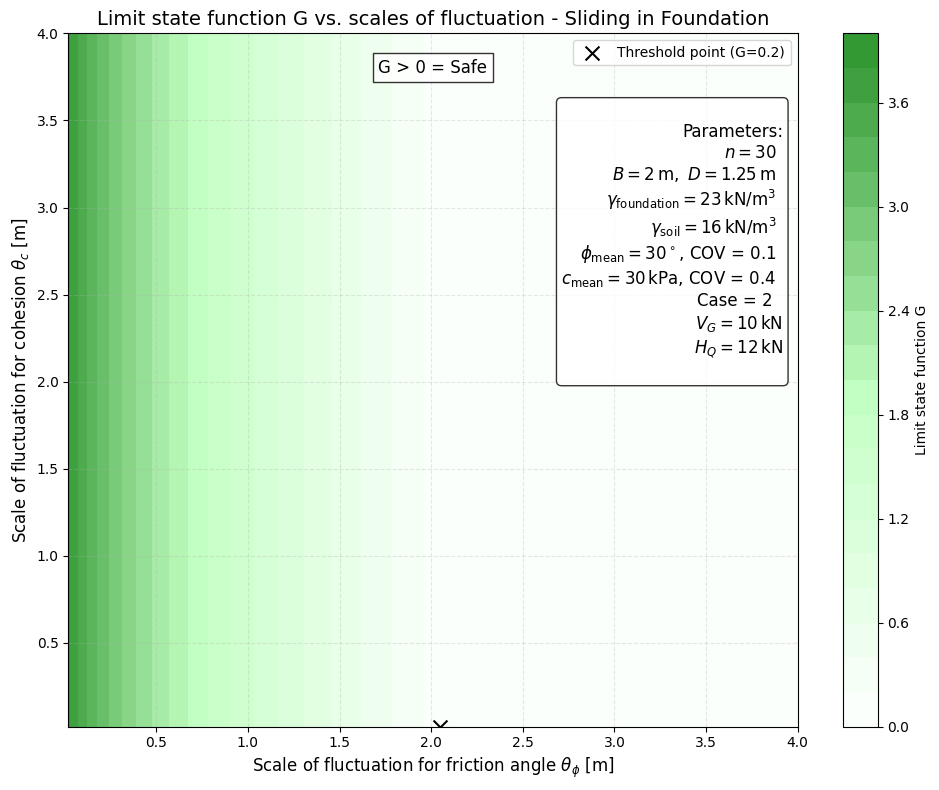

In [25]:
theta_phi_grid, theta_c_grid = np.meshgrid(theta_range, theta_range)

# Calculate G values for all combinations
G_values = np.zeros_like(theta_phi_grid)

for i in range(len(theta_range)):
    for j in range(len(theta_range)):
        G_values[i,j] = calculate_limit_state_function_G(theta_phi_grid[i,j], theta_c_grid[i,j],n, B,  D, 
                                                         gamma_foundation, gamma_soil,phi_mean, phi_cov,c_mean, c_cov,
                                                         V_G, H_Q, case)
# Create the plot
plt.figure(figsize=(10, 8))

# --- Make the white color at G=0 ---
G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red (near zero)
    (1, 1, 1),        # Pure white at zero
    (0.7, 1.0, 0.7),  # Light green (near zero)
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=512)

# Create contour plot
contour = plt.contourf(theta_phi_grid, theta_c_grid, G_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Limit state function G')

# Add contour lines
CS = plt.contour(theta_phi_grid, theta_c_grid, G_values, 
                levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the critical point (minimum G)
min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
plt.scatter(theta_phi_grid[min_idx], theta_c_grid[min_idx], 
           color='black', marker='x', s=100, label=f'Threshold point (G={G_values[min_idx]:.1f})')

# Formatting
plt.xlabel(r'Scale of fluctuation for friction angle $\theta_\phi$ [m]', fontsize=12)
plt.ylabel(r'Scale of fluctuation for cohesion $\theta_c$ [m]', fontsize=12)
plt.title('Limit state function G vs. scales of fluctuation - Sliding in Foundation', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

param_text = rf"""
Parameters:
$n = {n}$  
$B = {B}\,\mathrm{{m}},\ D = {D}\,\mathrm{{m}}$  
$\gamma_{{\mathrm{{foundation}}}} = {gamma_foundation}\,\mathrm{{kN/m^3}}$  
$\gamma_{{\mathrm{{soil}}}} = {gamma_soil}\,\mathrm{{kN/m^3}}$  
$\phi_{{\mathrm{{mean}}}} = {phi_mean}^\circ$, COV = {phi_cov}  
$c_{{\mathrm{{mean}}}} = {c_mean}\,\mathrm{{kPa}}$, COV = {c_cov}  
Case = {case}  
$V_G = {V_G}\,\mathrm{{kN}}$
$H_Q = {H_Q}\,\mathrm{{kN}}$
"""

plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()

Limit state function, related to normalized scale of fluctuation

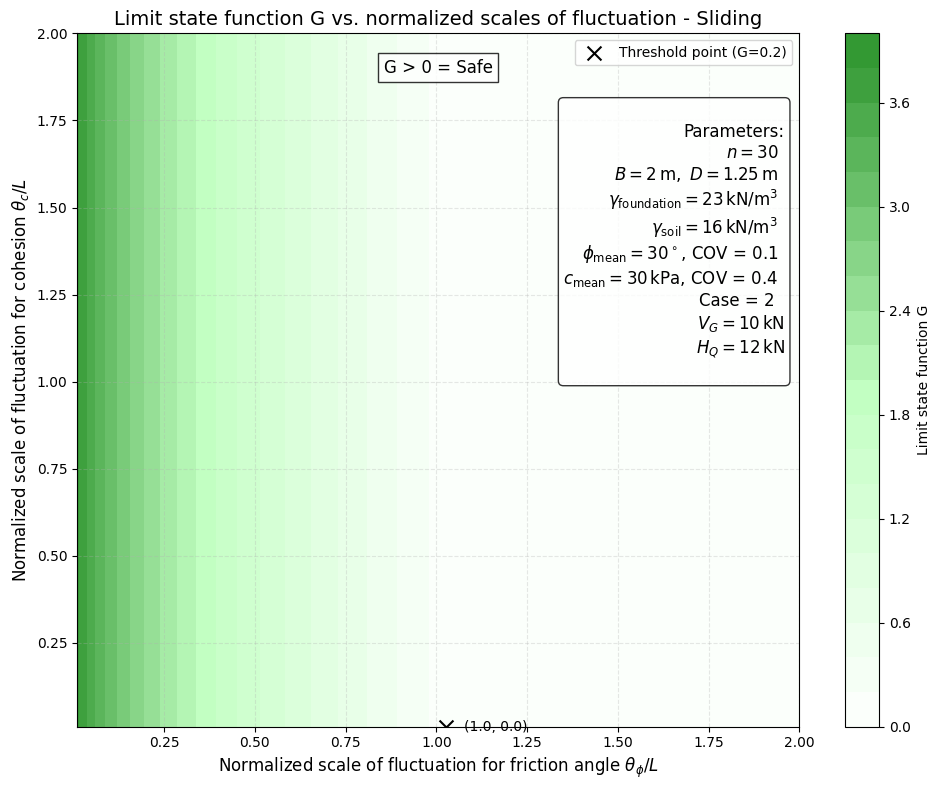

In [26]:
L_infl = B

# Create normalized grids (theta/L)
theta_phi_normalized = theta_phi_grid / L_infl
theta_c_normalized = theta_c_grid / L_infl

# Create the plot
plt.figure(figsize=(10, 8))

# Create contour plot using normalized values
contour = plt.contourf(theta_phi_normalized, theta_c_normalized, G_values, 
                      levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Limit state function G')

# Add contour lines using normalized values
CS = plt.contour(theta_phi_normalized, theta_c_normalized, G_values, 
                levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the critical point (minimum G) using normalized values
x_coord = theta_phi_normalized[min_idx]
y_coord = theta_c_normalized[min_idx]

# Add text label with coordinate values near the marker
plt.text(x_coord + 0.05, y_coord, f'({x_coord:.1f}, {y_coord:.1f})', 
         color='black', fontsize=10, va='center')

plt.scatter(theta_phi_normalized[min_idx], theta_c_normalized[min_idx], 
           color='black', marker='x', s=100, label=f'Threshold point (G={G_values[min_idx]:.1f})')

# Formatting with normalized axis labels
plt.xlabel(r'Normalized scale of fluctuation for friction angle $\theta_\phi/L$', fontsize=12)
plt.ylabel(r'Normalized scale of fluctuation for cohesion $\theta_c/L$', fontsize=12)
plt.title('Limit state function G vs. normalized scales of fluctuation - Sliding', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))


plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))


plt.tight_layout()
plt.show()

A Sensitivity Analysis on S1 and ST

                 ST   ST_conf
phi_cov    0.020563  0.003668
case       0.000000  0.000000
n          0.000237  0.000063
c_cov      0.000028  0.000027
theta_phi  0.002216  0.000722
theta_c    0.000000  0.000000
B          0.718079  0.093473
D          0.357545  0.065013
                 S1   S1_conf
phi_cov    0.018976  0.017943
case       0.000000  0.000000
n          0.000429  0.001960
c_cov     -0.000656  0.000662
theta_phi -0.000689  0.006802
theta_c    0.000000  0.000000
B          0.651133  0.098662
D          0.263951  0.070915
                                S2       S2_conf
(phi_cov, case)      -9.753081e-03  2.652179e-02
(phi_cov, n)         -9.868982e-03  2.654644e-02
(phi_cov, c_cov)     -9.567436e-03  2.646165e-02
(phi_cov, theta_phi) -8.873287e-03  2.668014e-02
(phi_cov, theta_c)   -9.753081e-03  2.652179e-02
(phi_cov, B)         -2.902143e-03  3.345156e-02
(phi_cov, D)         -1.659425e-03  2.886010e-02
(case, n)             2.873136e-18  6.290513e-18
(case, c_cov)      

c:\Users\glori\anaconda3\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


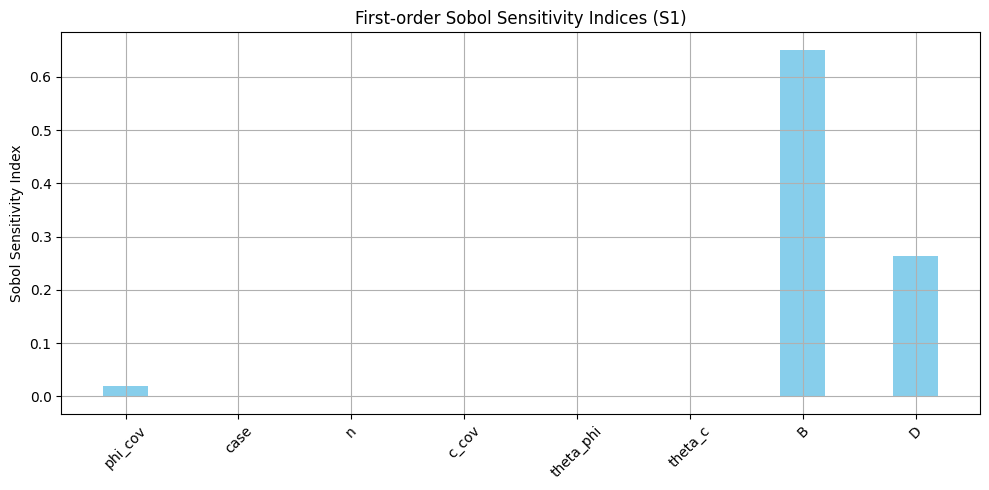

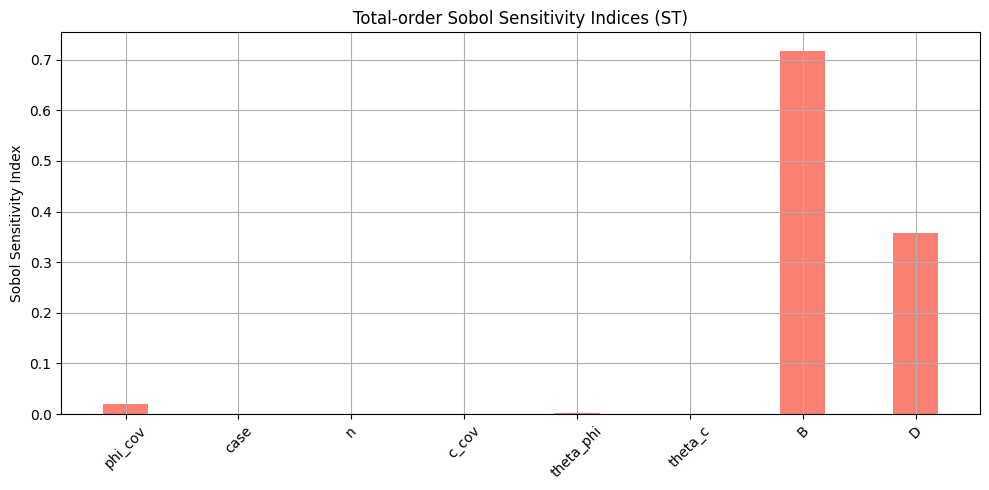

In [27]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol
import matplotlib.pyplot as plt

problem = {
    "num_vars": 8,
    "names": [
        "phi_cov",
        "case", 
        "n",
        "c_cov",
        "theta_phi", 
        "theta_c",
        "B", 
        "D", 
    ],
    "bounds": [
        [0.05, 0.15],
        [1, 3],
        [10, 30],
        [0.3, 0.5],
        [1, 50],
        [1, 50], 
        [1,9],
        [0.5,2]
    ]
}

# --- Generate Sobol samples ---
N = 512  # base sample size
param_values = sobol_sample.sample(problem, N, calc_second_order=True)

# --- Evaluate the model for each sample ---
def evaluate_model(X):
    outputs = []
    for row in X:
        try:
            phi_cov_SA, case_SA, n_SA, c_cov_SA, theta_phi_SA, theta_c_SA, B_SA, D_SA = row
            case_SA = int(round(case_SA))
            n_SA = int(round(n_SA))

            G = calculate_limit_state_function_G(
                theta_phi_SA,theta_c_SA,
                n_SA,B_SA, D_SA, 
                gamma_foundation,gamma_soil,
                phi_mean,phi_cov_SA,
                c_mean,c_cov_SA,
                V_G, H_Q, 
                case_SA)

            outputs.append(G)
        except:
            outputs.append(np.nan)
    return np.array(outputs)

Y = evaluate_model(param_values)
Y = np.nan_to_num(Y, nan=np.max(Y[np.isfinite(Y)]) + 1)  # Replace nan with large value

# --- Sobol analysis ---
Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# --- Plot S1 ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
x_labels = problem["names"]
x = np.arange(len(x_labels))

ax1.bar(x, Si["S1"], width=0.4, label="First-order (S1)", color='skyblue')
ax1.set_ylabel("Sobol Sensitivity Index")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_title("First-order Sobol Sensitivity Indices (S1)")
ax1.grid(True)
plt.tight_layout()
plt.show()

# --- Plot ST ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(x, Si["ST"], width=0.4, label="Total-order (ST)", color='salmon')
ax2.set_ylabel("Sobol Sensitivity Index")
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_title("Total-order Sobol Sensitivity Indices (ST)")
ax2.grid(True)
plt.tight_layout()
plt.show()


A S2 sensitivity analysis.

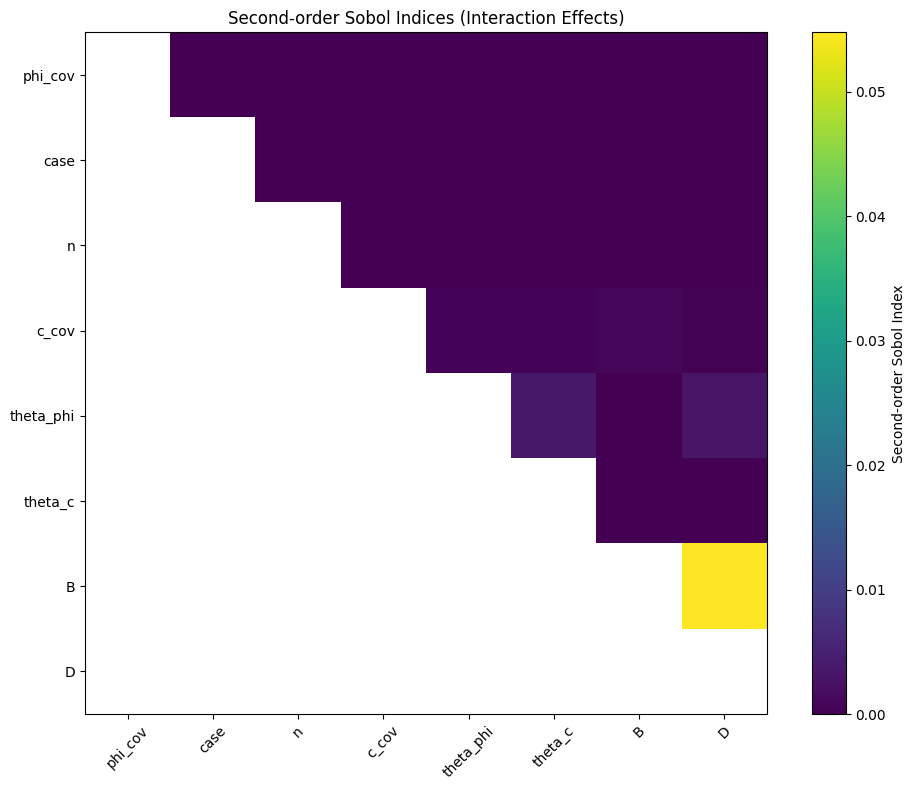

In [28]:

# --- Plot S2 (Interaction Effects) ---
fig3, ax3 = plt.subplots(figsize=(10, 8))

# Get the S2 matrix
S2_matrix = Si['S2']

# Create a mask for the upper triangle (since the matrix is symmetric)
mask = np.triu(np.ones_like(S2_matrix, dtype=bool))

# Create a heatmap of the S2 values
im = ax3.imshow(S2_matrix, cmap=cm.viridis, vmin=0, vmax=np.nanmax(S2_matrix))

# Add colorbar
cbar = fig3.colorbar(im, ax=ax3)
cbar.set_label('Second-order Sobol Index')

# Set ticks and labels
ax3.set_xticks(np.arange(len(problem['names'])))
ax3.set_yticks(np.arange(len(problem['names'])))
ax3.set_xticklabels(problem['names'], rotation=45)
ax3.set_yticklabels(problem['names'])

# Add values to each cell
for i in range(len(problem['names'])):
    for j in range(len(problem['names'])):
        if not mask[i,j]:  # Only show lower triangle
            if not np.isnan(S2_matrix[i,j]):
                text = ax3.text(j, i, f"{S2_matrix[i,j]:.2f}",
                              ha="center", va="center", color="w")

ax3.set_title("Second-order Sobol Indices (Interaction Effects)")
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- Interactive Plot Function ---

theta_vals = theta_range

def plot_Gleiten(
    vary='phi_theta',
    B=3.5,
    phi_theta=5, phi_cov=0.15,
    c_theta=5, c_cov=0.1,
    D=5):

    if vary == 'phi_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{\phi_1}$ (m)'
    elif vary == 'c_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{c}$ (m)'
    elif vary == 'phi_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{\phi_1}$'
    elif vary == 'c_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{c}$'
    elif vary == 'B':
        x_vals = B_vals
        x_label = r'Foundation thickness $B$ (m)'
    elif vary == 'D':
        x_vals = np.linspace(0.15, 1.5, 10)
        x_label = r'Depth $D$ (m)'
    else:
        return

    G_vals = []

    for x in x_vals:
        phi_theta_x = x if vary == 'phi_theta' else phi_theta
        c_theta_x = x if vary == 'c_theta' else c_theta

        phi_cov_x = x if vary == 'phi_cov' else phi_cov
        c_cov_x = x if vary == 'c_cov' else c_cov

        B_x = x if vary == 'B' else B
        D_x = x if vary == 'D' else D

        try:
            G = calculate_limit_state_function_G(
                theta_phi=phi_theta_x,
                theta_c=c_theta_x,
                n=30,
                B=B_x,
                D=D_x,
                gamma_foundation=23.6,
                gamma_soil=20,
                phi_mean=30,
                phi_cov=phi_cov_x,
                c_mean=20,
                c_cov=c_cov_x,
                V_G =V_G,
                H_Q = H_Q,
                case=2
            )
            G_vals.append(G)
        except:
            G_vals.append(np.nan)

    G_vals = np.array(G_vals)
    min_idx = np.nanargmin(G_vals)
    x_crit = x_vals[min_idx]
    G_crit = G_vals[min_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, G_vals, marker='o', linestyle='-', color='indigo')
    plt.plot(x_crit, G_crit, 'ro', label=f'Min G = {G_crit:.2f}\n@ {x_label} = {x_crit:.2f}')
    plt.annotate(f'{G_crit:.2f} at {x_label} = {x_crit:.2f}',
                 xy=(x_crit, G_crit),
                 xytext=(x_crit + 0.05 * (x_vals[-1] - x_vals[0]), G_crit + 0.1),
                 arrowprops=dict(facecolor='red', arrowstyle='->'),
                 fontsize=10, color='red')

    plt.xlabel(x_label)
    plt.ylabel(r'Limit State Function $G$')
    plt.title(f'Effect of {x_label} on $G$ for Gleiten')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Interactive UI ---

interact_ui_gleiten = widgets.interactive(
    plot_Gleiten,
    vary=widgets.Dropdown(
        options=['phi_theta', 'c_theta',
                 'phi_cov', 'c_cov',
                 'B', 'D'],
        value='phi_theta',
        description='Vary:',
    ),
    B=widgets.FloatSlider(min=0.5, max=20, step=0.1, value=3.5, description='B (m)'),
    D=widgets.FloatSlider(min=1, max=12, step=0.5, value=5, description='D (m)'),
    phi_theta=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ φ'),
    phi_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.15, description='CoV φ'),
    c_theta=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ c'),
    c_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.1, description='CoV c'),
)

display(interact_ui_gleiten)


interactive(children=(Dropdown(description='Vary:', options=('phi_theta', 'c_theta', 'phi_cov', 'c_cov', 'B', …

### We first explore the relationship between threshold theta and the width of the foundation.

gamma_soil (lower than 22 / higher than 23 ) gamma_wall, phi, n (if greater than 14),  H_Q and V_G have no influence

We assume theta for friction and cohesion are the same

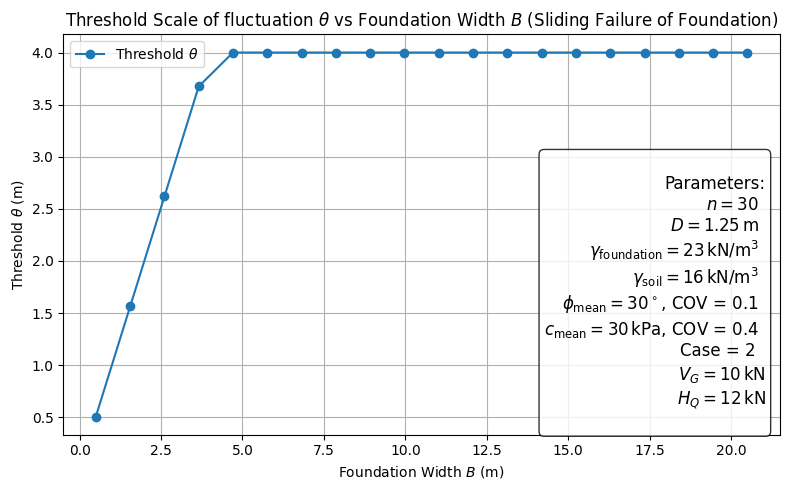

In [30]:
critical_theta_phi = []

for B_i in B_vals:
    G_vals = []
    for theta in theta_vals:
        try:
            G = calculate_limit_state_function_G(
                theta, theta,
                n, B_i,D,
                gamma_foundation,gamma_soil,
                phi_mean,phi_cov,
                c_mean, c_cov,
                V_G, H_Q,
                case)
            G_vals.append(G)
        except:
            G_vals.append(np.nan)

    G_vals = np.array(G_vals)
    min_idx = np.nanargmin(G_vals)
    critical_theta_phi.append(theta_vals[min_idx])



# --- Run and Plot ---
B_range = np.array(B_vals)
theta_phi_crit = np.array(critical_theta_phi)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(B_range, theta_phi_crit)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(B_range, theta_phi_crit, 'o-', label='Threshold $\\theta$')
# plt.plot(B_range, slope * B_range + intercept, 'r--', label='Linear Fit')

# # Regression equation
# eq_text = (
#     rf"$\theta = {slope:.1f} \cdot B + {intercept:.1f}$"
# )

# plt.text(
#     0.05, 0.95, eq_text,
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
# )


param_text = rf"""
Parameters:
$n = {n}$  
$D = {D}\,\mathrm{{m}}$  
$\gamma_{{\mathrm{{foundation}}}} = {gamma_foundation}\,\mathrm{{kN/m^3}}$  
$\gamma_{{\mathrm{{soil}}}} = {gamma_soil}\,\mathrm{{kN/m^3}}$  
$\phi_{{\mathrm{{mean}}}} = {phi_mean}^\circ$, COV = {phi_cov}  
$c_{{\mathrm{{mean}}}} = {c_mean}\,\mathrm{{kPa}}$, COV = {c_cov}  
Case = {case}  
$V_G = {V_G}\,\mathrm{{kN}}$
$H_Q = {H_Q}\,\mathrm{{kN}}$
"""


plt.text(0.98, 0.7, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))


plt.xlabel(r'Foundation Width $B$ (m)')
plt.ylabel(r'Threshold $\theta$ (m)')
plt.title(r'Threshold Scale of fluctuation $\theta$ vs Foundation Width $B$ (Sliding Failure of Foundation)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()